Importing required libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading the dataset files

Artists data

In [4]:
artists = pd.read_csv(
    "artists.dat", sep="\t", header=None, names=["artist_id", "name", "url", "picture_url"], encoding="latin1"
)

In [5]:
artists.head()

,artist_id,name,url,picture_url
0,id,name,url,pictureURL
1,1,MALICE MIZER,http://www.last.fm/music/MALICE+MIZER,http://userserve-ak.last.fm/serve/252/10808.jpg
2,2,Diary of Dreams,http://www.last.fm/music/Diary+of+Dreams,http://userserve-ak.last.fm/serve/252/3052066.jpg
3,3,Carpathian Forest,http://www.last.fm/music/Carpathian+Forest,http://userserve-ak.last.fm/serve/252/40222717...
4,4,Moi dix Mois,http://www.last.fm/music/Moi+dix+Mois,http://userserve-ak.last.fm/serve/252/54697835...


In [6]:
artists.shape

(17633, 4)

In [7]:
artists.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17633 entries, 0 to 17632
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   artist_id    17633 non-null  object
 1   name         17633 non-null  object
 2   url          17633 non-null  object
 3   picture_url  17189 non-null  object
dtypes: object(4)
memory usage: 551.2+ KB


In [8]:
artists.isnull().sum()

artist_id        0
name             0
url              0
picture_url    444
dtype: int64

Tags data

In [9]:
tags = pd.read_csv(
    "tags.dat", sep="\t", header=None, names=["tags_id", "tag"], encoding="latin1"
)

In [10]:
tags.head()

,tags_id,tag
0,tagID,tagValue
1,1,metal
2,2,alternative metal
3,3,goth rock
4,4,black metal


In [11]:
tags.shape

(11947, 2)

In [12]:
tags.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11947 entries, 0 to 11946
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   tags_id  11947 non-null  object
 1   tag      11947 non-null  object
dtypes: object(2)
memory usage: 186.8+ KB


In [13]:
tags.isnull().sum()

tags_id    0
tag        0
dtype: int64

User-Artist listening data

In [14]:
user_artists = pd.read_csv(
    "user_artists.dat", sep="\t", header=None, names=["user_id", "artist_id", "listen_count"], encoding="latin1"
)

In [15]:
user_artists.head()

,user_id,artist_id,listen_count
0,userID,artistID,weight
1,2,51,13883
2,2,52,11690
3,2,53,11351
4,2,54,10300


In [16]:
user_artists.shape

(92835, 3)

In [17]:
user_artists.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92835 entries, 0 to 92834
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       92835 non-null  object
 1   artist_id     92835 non-null  object
 2   listen_count  92835 non-null  object
dtypes: object(3)
memory usage: 2.1+ MB


In [18]:
user_artists.isnull().sum()

user_id         0
artist_id       0
listen_count    0
dtype: int64

In [19]:
user_artists["listen_count"] = pd.to_numeric(
    user_artists["listen_count"],
    errors="coerce"
)

In [20]:
user_artists.dtypes

user_id          object
artist_id        object
listen_count    float64
dtype: object

User friends data

In [21]:
user_friends = pd.read_csv(
    "user_friends.dat", sep="\t", header=None, names=["user_id", "friend_id"], encoding="latin1"
)

In [22]:
user_friends.head()

,user_id,friend_id
0,userID,friendID
1,2,275
2,2,428
3,2,515
4,2,761


In [23]:
user_friends.shape

(25435, 2)

In [24]:
user_friends.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25435 entries, 0 to 25434
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   user_id    25435 non-null  object
 1   friend_id  25435 non-null  object
dtypes: object(2)
memory usage: 397.5+ KB


In [25]:
user_friends.isnull().sum()

user_id      0
friend_id    0
dtype: int64

Understanding user and Artists

In [26]:
user_artists["user_id"].nunique()

1893

In [27]:
user_artists["artist_id"].nunique()

17633

Most listened Artists

In [28]:
top_artists = (
    user_artists.groupby("artist_id", as_index=False)["listen_count"]
    .sum()
    .sort_values(by="listen_count", ascending=False)
    .head(10)
)
top_artists

,artist_id,listen_count
9976,289,2393140.0
14629,72,1301308.0
16450,89,1291387.0
10009,292,1058405.0
12204,498,963449.0
14083,67,921198.0
9965,288,905423.0
14419,701,688529.0
9293,227,662116.0
10099,300,532545.0


In [29]:
top_artists.shape

(10, 2)

In [30]:
top_artists.head()

,artist_id,listen_count
9976,289,2393140.0
14629,72,1301308.0
16450,89,1291387.0
10009,292,1058405.0
12204,498,963449.0


Merge with artist names

In [31]:
top_artists = top_artists.merge(
    artists, on="artist_id", how="left"
)
top_artists[["name", "listen_count"]]

,name,listen_count
0,Britney Spears,2393140.0
1,Depeche Mode,1301308.0
2,Lady Gaga,1291387.0
3,Christina Aguilera,1058405.0
4,Paramore,963449.0
5,Madonna,921198.0
6,Rihanna,905423.0
7,Shakira,688529.0
8,The Beatles,662116.0
9,Katy Perry,532545.0


In [32]:
top_artists = top_artists.dropna(subset=["name"])

Visualization- Top artists

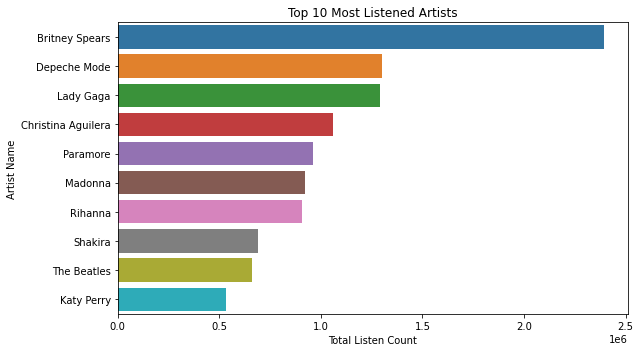

In [33]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=top_artists,
    x="listen_count",
    y="name"
)
plt.title("Top 10 Most Listened Artists")
plt.xlabel("Total Listen Count")
plt.ylabel("Artist Name")
plt.tight_layout()
plt.show()


user activity analysis

In [34]:
user_activity = user_artists.groupby("user_id")["artist_id"].count()
user_activity.describe()

count    1893.000000
mean       49.041204
std         5.947835
min         1.000000
25%        50.000000
50%        50.000000
75%        50.000000
max        50.000000
Name: artist_id, dtype: float64

Friends network analysis

In [35]:
friends_count = user_friends.groupby("user_id").count()
friends_count.describe

<bound method NDFrame.describe of          friend_id
user_id           
10               5
100              1
1001            62
1002            35
1003             3
...            ...
996              4
997              2
998             13
999             16
userID           1

[1893 rows x 1 columns]>

Tags analysis

In [36]:
tags.head()
tags["tag"].value_counts().head(10)

tag
tagValue                                     1
absolute bomb rock-punk track                1
gorgeous world pop track                     1
tribal womne of the amazon rocks my world    1
cool mano negra cover                        1
one of the best songs ive heard              1
killer rock song                             1
welsh indie rock in your face                1
wales rocks                                  1
fabulous melody in this indie rock gem       1
Name: count, dtype: int64

Recommendation System

Creating user-artist matrix 

In [37]:
user_artist_matrix = user_artists.pivot_table(
    index="user_id",
    columns="artist_id",
    values="listen_count",
    fill_value=0
)
user_artist_matrix.head()

artist_id,1,10,100,1000,10000,10001,10002,10003,10004,10005,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
user_id,,,,,,,,,,,,,,,,,,,,,
10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


each row shows how much a user listened to each artist.

In [42]:
user_artist_matrix.index[:10]

Index(['10', '100', '1001', '1002', '1003', '1004', '1005', '1006', '1007',
       '1008'],
      dtype='object', name='user_id')

In [43]:
type(user_artist_matrix.index[0])

str

Computing cosine similarity

In [38]:
from sklearn.metrics.pairwise import cosine_similarity
user_similarity = cosine_similarity(user_artist_matrix)

Converting to dataframe

In [39]:
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_artist_matrix.index,
    columns=user_artist_matrix.index
)
user_similarity_df.head()

user_id,10,100,1001,1002,1003,1004,1005,1006,1007,1008,...,99,990,991,993,994,995,996,997,998,999
user_id,,,,,,,,,,,,,,,,,,,,,
10,1.000000,0.123364,0.000000,0.000000,0.018000,0.005329,0.000000,0.016350,0.000000,0.019627,...,0.049435,0.111502,0.005337,0.05615,0.057911,0.000000,0.0,0.021242,0.000133,0.018298
100,0.123364,1.000000,0.000913,0.002588,0.055204,0.011224,0.013302,0.049388,0.004278,0.023637,...,0.050956,0.065310,0.027107,0.00000,0.011085,0.000000,0.0,0.058002,0.000000,0.037878
1001,0.000000,0.000913,1.000000,0.084399,0.003318,0.000224,0.000000,0.006779,0.071121,0.000000,...,0.000757,0.000000,0.000650,0.00000,0.001105,0.007024,0.0,0.000000,0.010926,0.020732
1002,0.000000,0.002588,0.084399,1.000000,0.144042,0.000000,0.000000,0.017188,0.012585,0.000000,...,0.347065,0.000000,0.000448,0.00000,0.005874,0.144370,0.0,0.000000,0.046665,0.000000
1003,0.018000,0.055204,0.003318,0.144042,1.000000,0.012945,0.000000,0.053497,0.018287,0.002550,...,0.021313,0.002250,0.001014,0.00000,0.004608,0.119562,0.0,0.000000,0.000611,0.010651


Recommend Artists to a user

In [46]:
def get_user_artists(user_id):
    return set(
        user_artist_matrix.loc[user_id][
            user_artist_matrix.loc[user_id] > 0
        ].index
    )


In [ ]:
def recommend_artists(user_id, top_n=5):
    user_id = str(user_id)

    similar_users = (
        user_similarity_df[user_id]
        .sort_values(ascending=False)
        .iloc[1:11]
    )

    user_artists_set = get_user_artists(user_id)

    candidate_scores = {}

    for sim_user in similar_users.index:
        sim_score = similar_users[sim_user]
        sim_artists = user_artist_matrix.loc[sim_user]

        for artist_id, count in sim_artists.items():
            if count > 0 and artist_id not in user_artists_set:
                candidate_scores[artist_id] = candidate_scores.get(artist_id, 0) + sim_score * count


    recommendations = (
        pd.Series(candidate_scores)
        .sort_values(ascending=False)
        .head(top_n)
    )

    return recommendations


In [48]:
recommend_artists("10")


1510    1923.815809
615     1559.360373
190     1543.574897
1118    1541.199957
72      1499.710257
dtype: float64

In [49]:
recommended = recommend_artists("10")

recommended_artists = (
    recommended
    .reset_index()
    .merge(artists, left_on="index", right_on="artist_id", how="left")
    [["name", 0]]
)

recommended_artists.columns = ["Artist Name", "Recommendation Score"]
recommended_artists


,Artist Name,Recommendation Score
0,Black Rebel Motorcycle Club,1923.815809
1,Elliott Smith,1559.360373
2,Muse,1543.574897
3,A Perfect Circle,1541.199957
4,Depeche Mode,1499.710257


Cosine similarity

Normalizing data

In [50]:
from sklearn.preprocessing import normalize

user_artist_normalized = normalize(user_artist_matrix)

Apply k-means

In [51]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

user_clusters = kmeans.fit_predict(user_artist_normalized)

Attaching cluster labels to users

In [52]:
user_cluster_df = pd.DataFrame({
    "user_id": user_artist_matrix.index,
    "cluster": user_clusters
})

user_cluster_df.head()

,user_id,cluster
0,10,2
1,100,2
2,1001,1
3,1002,0
4,1003,1


Finding top artists per cluster

In [53]:
user_artist_matrix["cluster"] = user_clusters

cluster_profiles = (
    user_artist_matrix
    .groupby("cluster")
    .mean()
)

Top artist in each cluster

In [54]:
for cluster_id in cluster_profiles.index:
    print(f"\nCluster {cluster_id} top artists:")
    top_artists = (
        cluster_profiles.loc[cluster_id]
        .sort_values(ascending=False)
        .head(5)
    )
    print(top_artists)


Cluster 0 top artists:
artist_id
89     2967.246006
292    2583.012780
288    2028.169329
67     1768.626198
289    1668.022364
Name: 0, dtype: float64

Cluster 1 top artists:
artist_id
498    595.804469
378    415.107076
511    401.504655
486    383.424581
163    350.382682
Name: 1, dtype: float64

Cluster 2 top artists:
artist_id
227    1568.750809
154     892.226537
190     874.177994
207     752.954693
903     462.216828
Name: 2, dtype: float64

Cluster 3 top artists:
artist_id
72      12922.181818
1014      662.556818
1713      628.306818
173       481.590909
1072      447.159091
Name: 3, dtype: float64

Cluster 4 top artists:
artist_id
289    16299.259259
89      2125.898148
288     1792.916667
292     1679.120370
67      1653.055556
Name: 4, dtype: float64
